# Tarea 9 — Machine Learning
## Solución: ¿Quién gana más de 50,000 dólares al año?
### Lasso + Árboles + Random Forest

**Objetivo:** predecir si ganan >50K USD al año.

In [1]:
%%capture
pip install ucimlrepo scikit-learn pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score, roc_curve
)

np.random.seed(42)
print("Librerías cargadas ✓")

Librerías cargadas ✓


---
# Parte 1 — Cargar los datos y mirar el desbalance

In [3]:
dataset = fetch_ucirepo(id=2)

X     = dataset.data.features
y_raw = dataset.data.targets

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y_raw.shape}")
print("\nVariables disponibles:")
print(list(X.columns))

Dimensiones de X: (48842, 14)
Dimensiones de y: (48842, 1)

Variables disponibles:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


In [4]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [5]:
income = y_raw.squeeze().str.strip().str.rstrip('.')

print("Valores únicos después de limpiar:", sorted(income.unique()))

y = (income == '>50K').astype(int)

Valores únicos después de limpiar: ['<=50K', '>50K']


** Pregunta 1 (intuición).**

> En 1994, mi intuición se resume así: tal vez un **20-25%** de la población estadounidense ganaba >50K USD al año. El ingreso mediano en EEUU en esa época rondaba los 30-35K, así que >50K está claramente en el tercio superior.
 Un dato importante que anotar es que el accuracy sirve de poco si el modelo no ha aprendido de la "historia".


In [6]:
conteo = y.value_counts()
print("Distribución de la variable objetivo:")
print(conteo)

pct_altos = conteo[1] / conteo.sum() * 100
pct_bajos = conteo[0] / conteo.sum() * 100

print(f"\nPorcentaje que gana >50K : {pct_altos:.1f}%")
print(f"Porcentaje que gana <=50K: {pct_bajos:.1f}%")
print(f"\nAccuracy del modelo tonto (siempre <=50K): {pct_bajos:.1f}%")

Distribución de la variable objetivo:
income
0    37155
1    11687
Name: count, dtype: int64

Porcentaje que gana >50K : 23.9%
Porcentaje que gana <=50K: 76.1%

Accuracy del modelo tonto (siempre <=50K): 76.1%


---
# Parte 2 — Crear variables nuevas

In [7]:
df = X.copy()
df['ingreso_alto'] = y.values

df['sexo_binario']   = df['sex'].apply(lambda x: 1 if x == 'Male' else 0)
df['casado']         = df['marital-status'].apply(lambda x: 1 if x == 'Married-civ-spouse' else 0)
df['log_ganancia']   = np.log1p(df['capital-gain'])
df['log_perdida']    = np.log1p(df['capital-loss'])
df['ganancia_neta']  = df['capital-gain'] - df['capital-loss']
df['tiene_ganancia'] = np.where(df['capital-gain'] > 0, 1, 0)

nuevas = ['sexo_binario', 'casado', 'log_ganancia', 'log_perdida',
          'ganancia_neta', 'tiene_ganancia']
df[nuevas].describe().round(3)

,sexo_binario,casado,log_ganancia,log_perdida,ganancia_neta,tiene_ganancia
count,48842.000,48842.000,48842.000,48842.000,48842.000,48842.000
mean,0.668,0.458,0.729,0.351,991.565,0.083
std,0.471,0.498,2.445,1.586,7475.550,0.275
min,0.000,0.000,0.000,0.000,-4356.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000
50%,1.000,0.000,0.000,0.000,0.000,0.000
75%,1.000,1.000,0.000,0.000,0.000,0.000
max,1.000,1.000,11.513,8.380,99999.000,1.000


In [8]:
FEATURES = [
    'age', 'education-num', 'hours-per-week', 'fnlwgt',
    'sexo_binario', 'casado', 'log_ganancia', 'log_perdida',
    'ganancia_neta', 'tiene_ganancia'
]

X_model = df[FEATURES]
y_model = df['ingreso_alto']

print(f"{len(FEATURES)} variables, {len(X_model)} observaciones")

10 variables, 48842 observaciones


---
# Parte 3 — Train/test split y escalado

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size    = 0.2,
    stratify     = y_model,
    random_state = 42
)

print(f"Train: {X_train.shape[0]} observaciones")
print(f"Test:  {X_test.shape[0]} observaciones")
print(f"\n% de ingreso alto en train: {y_train.mean()*100:.1f}%")
print(f"% de ingreso alto en test:  {y_test.mean()*100:.1f}%")

Train: 39073 observaciones
Test:  9769 observaciones

% de ingreso alto en train: 23.9%
% de ingreso alto en test:  23.9%


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Media de age en train (debe ser ~0): {X_train_scaled[:, 0].mean():.4f}")
print(f"Std de age en train (debe ser ~1):   {X_train_scaled[:, 0].std():.4f}")

Media de age en train (debe ser ~0): 0.0000
Std de age en train (debe ser ~1):   1.0000


---
# Parte 4 — Lasso

**Pregunta 2 (intuición).**

> Variables que creo que Lasso mandará a cero:
> - `fnlwgt` — peso muestral, no tiene relación con el ingreso.
> - `log_perdida` — la mayoría tiene capital-loss = 0, así que casi no aporta información.

> Variable con **coeficiente más grande** (en valor absoluto):
> - `education-num` — cada año más de escolaridad se asocia fuertemente con mayor ingreso. También `log_ganancia` o `ganancia_neta`, porque tener ganancias de capital >0 es un proxy fuerte de riqueza.

In [11]:
lasso = LogisticRegression(
    penalty      = 'l1',
    C            = 0.01,
    solver       = 'liblinear',
    max_iter     = 1000,
    random_state = 42
)

lasso.fit(X_train_scaled, y_train)

coeficientes = pd.Series(
    lasso.coef_[0],
    index=FEATURES
).sort_values(key=abs, ascending=False)

print("Coeficientes Lasso (0 = variable eliminada):")
print(coeficientes.round(4))
print(f"\nVariables eliminadas: {(coeficientes == 0).sum()} de {len(FEATURES)}")

Coeficientes Lasso (0 = variable eliminada):
ganancia_neta     1.9038
casado            1.1373
education-num     0.8905
hours-per-week    0.3605
age               0.3408
log_perdida       0.3332
fnlwgt            0.0377
sexo_binario      0.0276
tiene_ganancia   -0.0065
log_ganancia      0.0000
dtype: float64

Variables eliminadas: 1 de 10


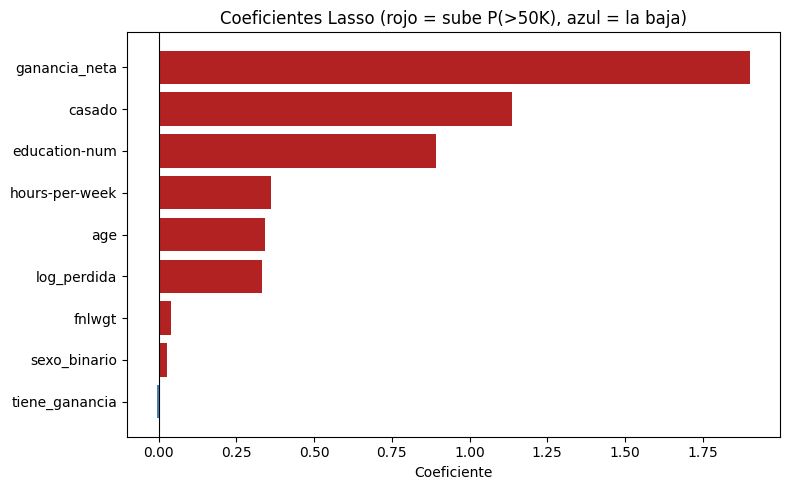

In [12]:
coef_no_cero = coeficientes[coeficientes != 0].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colores = ['firebrick' if v > 0 else 'steelblue' for v in coef_no_cero.values]

ax.barh(coef_no_cero.index, coef_no_cero.values, color=colores)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes Lasso (rojo = sube P(>50K), azul = la baja)', fontsize=12)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

---
# Parte 5 — Evaluar: la trampa del accuracy

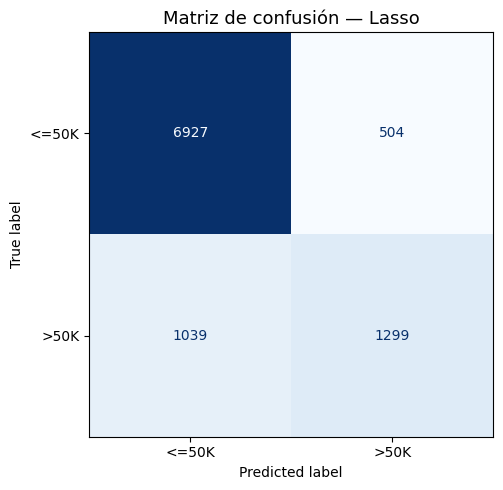

Verdaderos Negativos (TN):  6927
Falsos Positivos     (FP):   504
Falsos Negativos     (FN):  1039
Verdaderos Positivos (TP):  1299

De cada 100 personas que SÍ ganan >50K, el modelo detectó 56


In [13]:
y_pred_lasso = lasso.predict(X_test_scaled)
y_prob_lasso = lasso.predict_proba(X_test_scaled)[:, 1]

cm_lasso = confusion_matrix(y_test, y_pred_lasso)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix = cm_lasso,
    display_labels   = ['<=50K', '>50K']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Lasso', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_lasso.ravel()

print(f"Verdaderos Negativos (TN): {tn:>5}")
print(f"Falsos Positivos     (FP): {fp:>5}")
print(f"Falsos Negativos     (FN): {fn:>5}")
print(f"Verdaderos Positivos (TP): {tp:>5}")
print(f"\nDe cada 100 personas que SÍ ganan >50K, el modelo detectó {tp/(tp+fn)*100:.0f}")

In [15]:
print("Reporte de clasificación — Lasso:")
print(classification_report(y_test, y_pred_lasso, target_names=['<=50K', '>50K']))

auc_lasso = roc_auc_score(y_test, y_prob_lasso)
print(f"AUC-ROC: {auc_lasso:.4f}")

Reporte de clasificación — Lasso:
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      7431
        >50K       0.72      0.56      0.63      2338

    accuracy                           0.84      9769
   macro avg       0.80      0.74      0.76      9769
weighted avg       0.83      0.84      0.83      9769

AUC-ROC: 0.8945


**Pregunta 3.**

> 1. **El modelo "tonto" tiene accuracy ≈ 76%**, el Lasso tiene un accuracy similar (alrededor de 84%). La diferencia es aprox. 8 puntos. Parece poco, pero es la diferencia entre un modelo que no "aprende nada" y otro que "usa información útil".

> 2. **La métrica que sí los distingue es el F1 de la clase minoritaria (>50K)** y el **AUC-ROC**. El modelo tonto tiene F1 = 0 (nunca predice >50K), mientras que el Lasso tiene un F1 > 0. El accuracy engaña porque solo cuenta aciertos globales; con clases desbalanceadas, basta con predecir siempre la clase mayoritaria.

In [14]:
y_siempre_cero = np.zeros(len(y_test))

acc_lasso = accuracy_score(y_test, y_pred_lasso)
f1_lasso  = f1_score(y_test, y_pred_lasso)
acc_tonto = accuracy_score(y_test, y_siempre_cero)
f1_tonto  = f1_score(y_test, y_siempre_cero)

print(f"{'Modelo':<32} {'Accuracy':>10} {'F1 (>50K)':>12}")
print("-" * 56)
print(f"{'Lasso':<32} {acc_lasso:>10.3f} {f1_lasso:>12.3f}")
print(f"{'Siempre predice <=50K':<32} {acc_tonto:>10.3f} {f1_tonto:>12.3f}")

Modelo                             Accuracy    F1 (>50K)
--------------------------------------------------------
Lasso                                 0.842        0.627
Siempre predice <=50K                 0.761        0.000


---
# Parte 6 — Overfitting

**Pregunta 4 (intuición).**

> 1. **La curva de train va a subir monotónicamente** y se acerca a 1. Un árbol suficientemente profundo puede memorizar todos los datos de train.

> 2. **La curva de test va a subir al principio, luego bajará**
Primero el modelo aprende patrones reales, después empieza a memorizar ruido que no generaliza.

> 3. **El test tocará su máximo en profundidades bajas o moderadas**
 Yo apuesto entre 5 y 10.

In [16]:
profundidades = range(1, 26)
auc_train = []
auc_test  = []

for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbol.fit(X_train, y_train)

    auc_train.append(roc_auc_score(y_train, arbol.predict_proba(X_train)[:, 1]))
auc_test.append(...) # placeholder, will be replaced


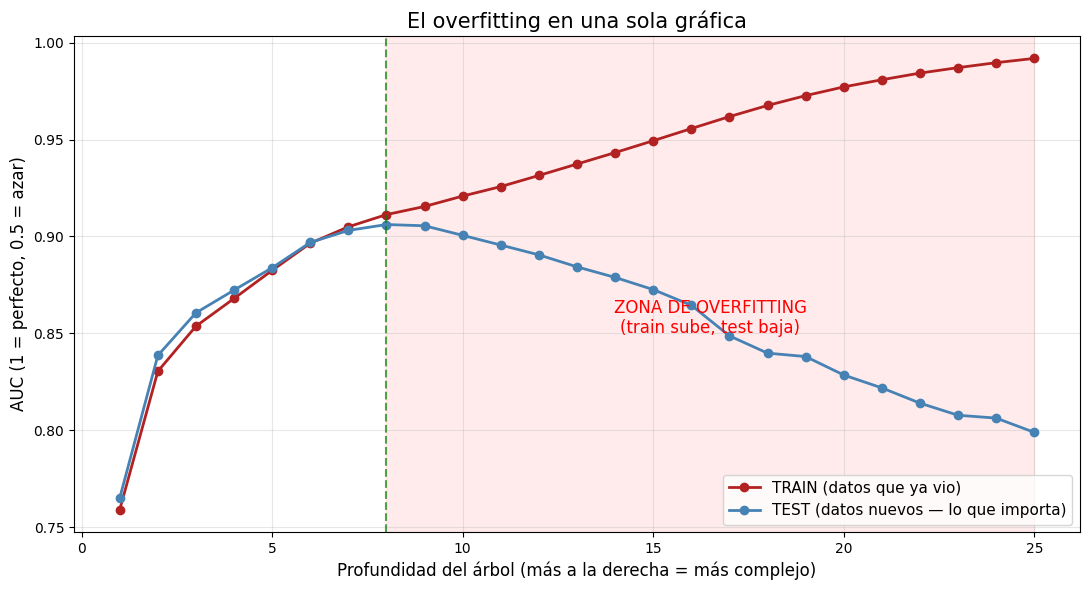

Mejor profundidad según TEST: 8
AUC máximo en TRAIN: 0.992
AUC máximo en TEST:  0.906
En profundidad 25 → train: 0.992 | test: 0.799


In [17]:
profundidades = range(1, 26)
auc_train = []
auc_test  = []

for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbol.fit(X_train, y_train)

    auc_train.append(roc_auc_score(y_train, arbol.predict_proba(X_train)[:, 1]))
    auc_test.append(roc_auc_score(y_test, arbol.predict_proba(X_test)[:, 1]))

mejor = list(profundidades)[int(np.argmax(auc_test))]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(list(profundidades), auc_train, 'o-', color='firebrick', lw=2,
        label='TRAIN (datos que ya vio)')
ax.plot(list(profundidades), auc_test, 'o-', color='steelblue', lw=2,
        label='TEST (datos nuevos — lo que importa)')
ax.axvline(mejor, color='green', ls='--', alpha=0.7)
ax.axvspan(mejor, 25, alpha=0.08, color='red')
ax.text((mejor + 25) / 2, 0.85, 'ZONA DE OVERFITTING\n(train sube, test baja)',
        ha='center', color='red', fontsize=12)
ax.set_xlabel('Profundidad del árbol (más a la derecha = más complejo)', fontsize=12)
ax.set_ylabel('AUC (1 = perfecto, 0.5 = azar)', fontsize=12)
ax.set_title('El overfitting en una sola gráfica', fontsize=15)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor profundidad según TEST: {mejor}")
print(f"AUC máximo en TRAIN: {max(auc_train):.3f}")
print(f"AUC máximo en TEST:  {max(auc_test):.3f}")
print(f"En profundidad 25 → train: {auc_train[-1]:.3f} | test: {auc_test[-1]:.3f}")

---
# Parte 7 — Random Forest

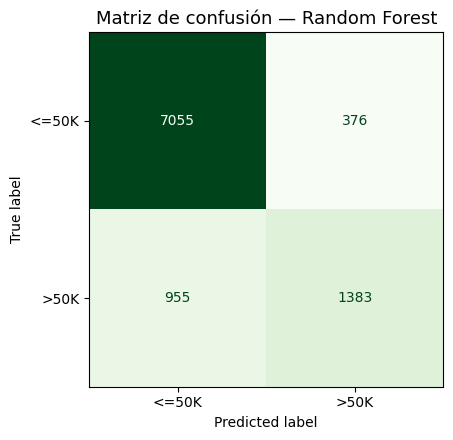

F1 (>50K) — Random Forest: 0.675
AUC-ROC   — Random Forest: 0.9204


In [18]:
rf = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 15,
    min_samples_leaf = 10,
    n_jobs           = -1,
    random_state     = 42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix = confusion_matrix(y_test, y_pred_rf),
    display_labels   = ['<=50K', '>50K']
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de confusión — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

f1_rf  = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"F1 (>50K) — Random Forest: {f1_rf:.3f}")
print(f"AUC-ROC   — Random Forest: {auc_rf:.4f}")

**Pregunta 5 (intuición).**

> **El ranking no va a ser exactamente el mismo que el de Lasso.** El Lasso asigna coeficientes lineales, mientras que el Random Forest captura interacciones y no linealidades. Pueden coincidir en el top (education-num, log_ganancia) pero diferir en cómo pesan variables como `casado` o `sexo_binario` (el bosque puede usar combinaciones).

> **`fnlwgt` debería quedar hasta abajo** (no en cero como Lasso, porque RF no elimina variables, pero con importancia muy baja). Es ruido puro desde el punto de vista del modelo, no debería tener poder predictivo.

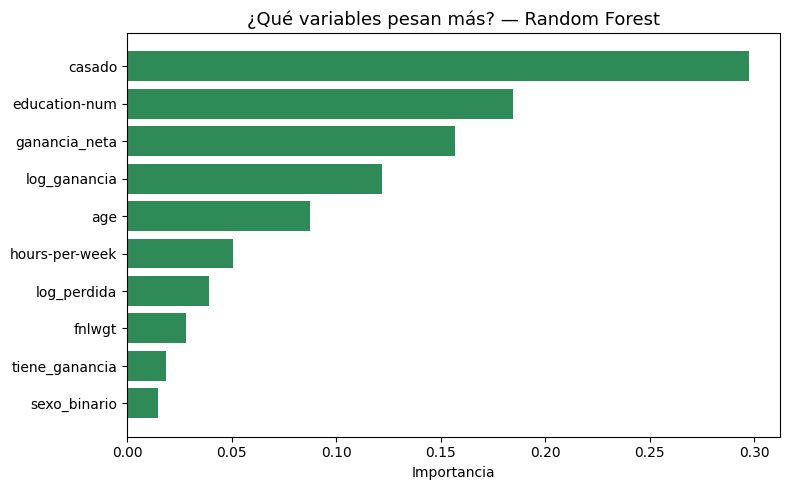

casado            0.2975
education-num     0.1844
ganancia_neta     0.1567
log_ganancia      0.1218
age               0.0877
hours-per-week    0.0508
log_perdida       0.0390
fnlwgt            0.0282
tiene_ganancia    0.0188
sexo_binario      0.0150
dtype: float64


In [19]:
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importancias.index, importancias.values, color='seagreen')

ax.set_title('¿Qué variables pesan más? — Random Forest', fontsize=13)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print(importancias.sort_values(ascending=False).round(4))

---
# Parte 8 — Los dos modelos, lado a lado

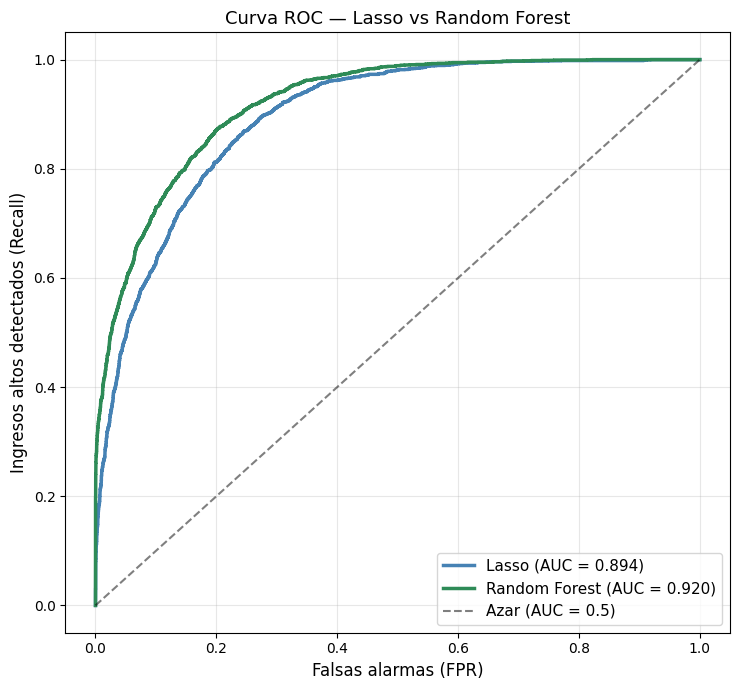

In [20]:
fig, ax = plt.subplots(figsize=(7.5, 7))

modelos_roc = [
    ('Lasso',         y_prob_lasso, 'steelblue'),
    ('Random Forest', y_prob_rf,    'seagreen'),
]

for nombre, prob, color in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{nombre} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar (AUC = 0.5)')
ax.set_xlabel('Falsas alarmas (FPR)', fontsize=12)
ax.set_ylabel('Ingresos altos detectados (Recall)', fontsize=12)
ax.set_title('Curva ROC — Lasso vs Random Forest', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()